# SLA (Delivery Performance SLA Analysis)


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

2- Load Dataset


In [2]:
data_path=[]

data_path = "../Data"

# SLA (Delivery Performance SLA Analysis)

customers = pd.read_csv(os.path.join(data_path, "olist_customers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(data_path, "olist_geolocation_dataset.csv"))
order_items = pd.read_csv(os.path.join(data_path, "olist_order_items_dataset.csv"))
order_payments = pd.read_csv(os.path.join(data_path, "olist_order_payments_dataset.csv"))
order_reviews = pd.read_csv(os.path.join(data_path, "olist_order_reviews_dataset.csv"))
orders = pd.read_csv(os.path.join(data_path, "olist_orders_dataset.csv"))
products = pd.read_csv(os.path.join(data_path, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(data_path, "olist_sellers_dataset.csv"))
product_category = pd.read_csv(os.path.join(data_path, "product_category_name_translation.csv"))

3-Data Understanding

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00


In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [5]:
orders.shape

(99441, 8)

In [6]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

4-Data Cleaning

In [7]:
orders.duplicated().sum()

np.int64(0)

5- Datetime Conversion

In [8]:
# Dates
date_columns = [
    'order_purchase_timestamp' ,
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

# Convert columns to datetime
for c in date_columns:
    orders[c] = pd.to_datetime(orders[c])
    
orders[date_columns].dtypes


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

6-Data Preparation

In [9]:
delivered_orders = orders[
    orders['order_status'] == 'delivered'
].copy()


7- Feature Engineering

In [10]:
# Actual Delivery Time
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date']
    -
    delivered_orders['order_purchase_timestamp']
).dt.days

# Estimated Delivery Time
delivered_orders['estimated_delivery_days'] = (
    delivered_orders['order_estimated_delivery_date']
    -
    delivered_orders['order_purchase_timestamp']
).dt.days

# Delay Days
delivered_orders['delay_days'] = (
    delivered_orders['delivery_days']
    -
    delivered_orders['estimated_delivery_days']
)

# Status
delivered_orders['sla_status'] = np.where(
    delivered_orders['delay_days'] <= 0,
    'On Time',
    'Delayed'
)

orders['org_to_carrier_time'] = orders['order_delivered_carrier_date'] - orders['order_approved_at']
orders['carrier_to_customer_time'] = orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']
orders['actual_arrival_time'] = orders['order_delivered_customer_date'] - orders['order_approved_at']
orders['apply_SLA'] = orders['order_delivered_customer_date'] <= orders['order_estimated_delivery_date']
orders['delivery_delay']= orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']

8 - Best-selling categories


In [11]:
selling_categories=products["product_category_name"].value_counts().head(10)
selling_categories

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

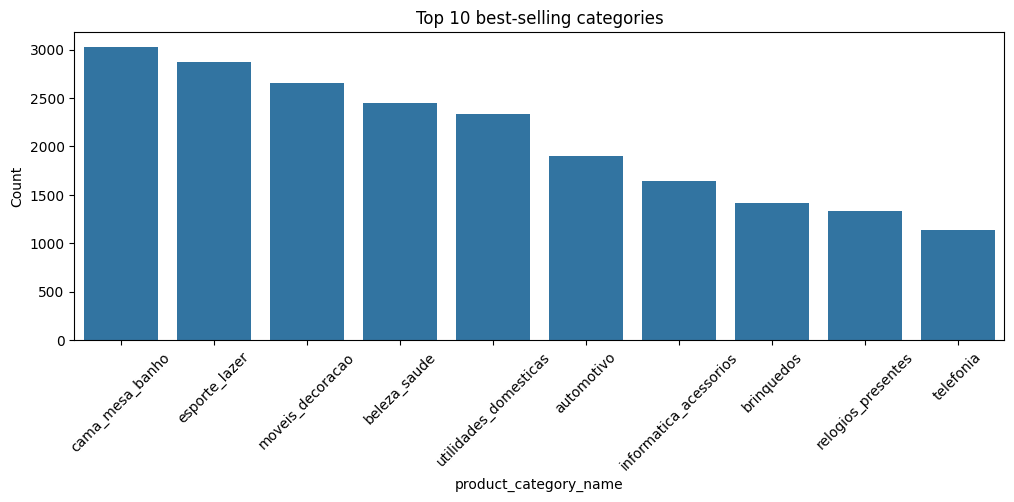

In [12]:
plt.figure(figsize=(12,4))
sns.barplot(selling_categories)
plt.title("Top 10 best-selling categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

9- Are there categories that experience longer delivery times than others?

In [13]:
items_products=pd.merge(order_items,products,on="product_id")
order_items_products=pd.merge(orders,items_products,on="order_id") 

order_items_products["delivery_time"] = (
    order_items_products["order_delivered_customer_date"]
    - order_items_products["order_purchase_timestamp"]
)

category_delivery = (
    order_items_products
    .groupby("product_category_name")["delivery_time"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

category_delivery

product_category_name
moveis_escritorio                20 days 20:11:36.438848
artigos_de_natal                 15 days 17:46:28.400000
fashion_calcados                 15 days 10:35:26.147859
seguros_e_servicos                      15 days 03:19:00
casa_conforto_2                         14 days 13:45:48
moveis_colchao_e_estofado        14 days 10:23:27.567567
eletrodomesticos_2               13 days 21:45:14.025974
moveis_sala                      13 days 19:04:49.575757
ferramentas_jardim               13 days 17:00:44.029990
fashion_underwear_e_moda_praia   13 days 16:57:00.472440
Name: delivery_time, dtype: timedelta64[us]

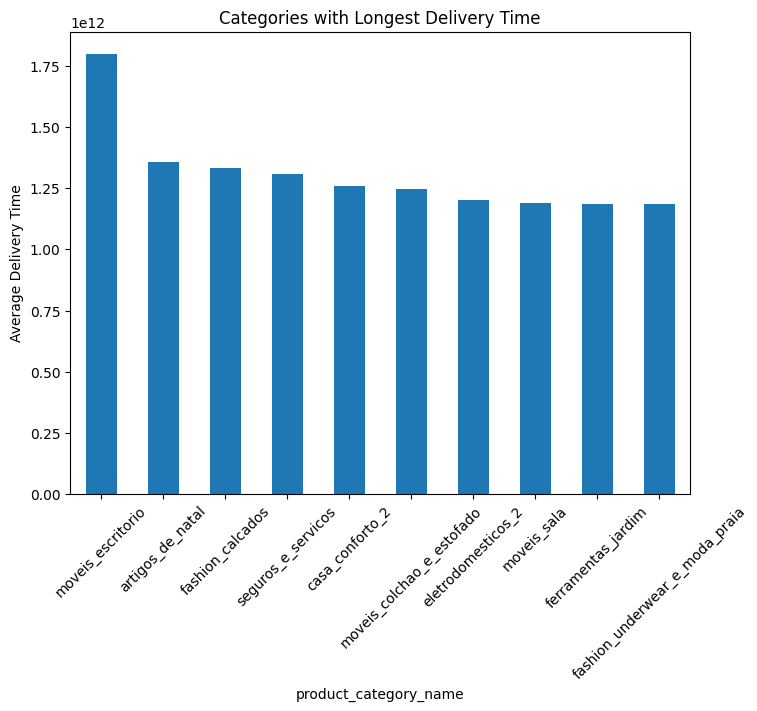

In [14]:
category_delivery.plot(kind="bar", figsize=(8,6))

plt.title("Categories with Longest Delivery Time")
plt.ylabel("Average Delivery Time")
plt.xticks(rotation=45)

plt.show()

In [15]:
customer_with_orders=pd.merge(customers,orders,on="customer_id")

orders_with_state=customer_with_orders.groupby("customer_state")["order_id"].count().sort_values(ascending=False).head(10)
orders_with_state

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: order_id, dtype: int64

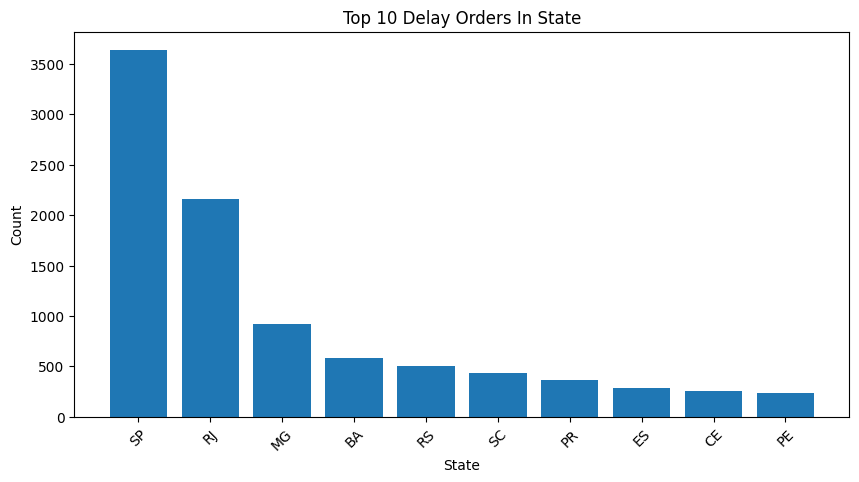

In [16]:
# Top 10 States with Most Delayed Orders

state_delay_count = (customer_with_orders[ customer_with_orders['apply_SLA'] == False]
    .groupby('customer_state')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    state_delay_count.index,
    state_delay_count.values
)

plt.title('Top 10 Delay Orders In State')
plt.xlabel('State')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

Delivery delays are most common in SP (São Paulo) with 3,638 delayed orders, followed by RJ (Rio de Janeiro) and MG (Minas Gerais). This suggests that states with the highest order volumes also tend to experience more delivery delays, possibly due to heavier logistics demand.

In [17]:
# 1. التركيز على الطلبات المستلمة فقط
delivered_df = orders[orders['order_status'] == 'delivered'].copy()
# 2. تحويل التواريخ من نصوص إلى Datetime
delivered_df['order_purchase_timestamp'] = pd.to_datetime(delivered_df['order_purchase_timestamp'])
delivered_df['order_delivered_customer_date'] = pd.to_datetime(delivered_df['order_delivered_customer_date'])
delivered_df['order_estimated_delivery_date'] = pd.to_datetime(delivered_df['order_estimated_delivery_date'])

# 3. هندسة المتغيرات اللوجستية الأساسية (Feature Engineering)
delivered_df['actual_days'] = (delivered_df['order_delivered_customer_date'] - delivered_df['order_purchase_timestamp']).dt.days
delivered_df['estimated_days'] = (delivered_df['order_estimated_delivery_date'] - delivered_df['order_purchase_timestamp']).dt.days
delivered_df['delay_days'] = (delivered_df['order_delivered_customer_date'] - delivered_df['order_estimated_delivery_date']).dt.days

# عرض حجم البيانات النهائي وشكل الأعمدة الجديدة
print(f"Total Delivered Orders Analyzed: {delivered_df.shape[0]}")
print(delivered_df[['actual_days', 'estimated_days', 'delay_days']].head())

Total Delivered Orders Analyzed: 96478
   actual_days  estimated_days  delay_days
0          8.0              15        -8.0
1         13.0              19        -6.0
2          9.0              26       -18.0
3         13.0              26       -13.0
4          2.0              12       -10.0


# SLA Compliance
• What % of orders are delivered on time?

• What % are delayed?

• How large are the delays (1 day vs 10 days)?

In [18]:
# 1. What % of orders are delivered on time?
on_time_rate = (
    delivered_orders['sla_status']
    .eq('On Time')
    .mean() * 100
)

print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")
# What % are delayed
late_rate = (
    delivered_orders['sla_status']
    .eq('Delayed')
    .mean() * 100
)

print(f"Late Delivery Rate: {late_rate:.2f}%")
# Average Delay
avg_delay = delivered_orders.loc[
    delivered_orders['delay_days'] > 0,
    'delay_days'
].mean()

print(f"Average Delay: {avg_delay:.2f} days")

# Maximum Delay
max_delay = delivered_orders['delay_days'].max()

print(f"Maximum Delay: {max_delay} days")

On-Time Delivery Rate: 92.42%
Late Delivery Rate: 7.58%
Average Delay: 10.12 days
Maximum Delay: 189.0 days


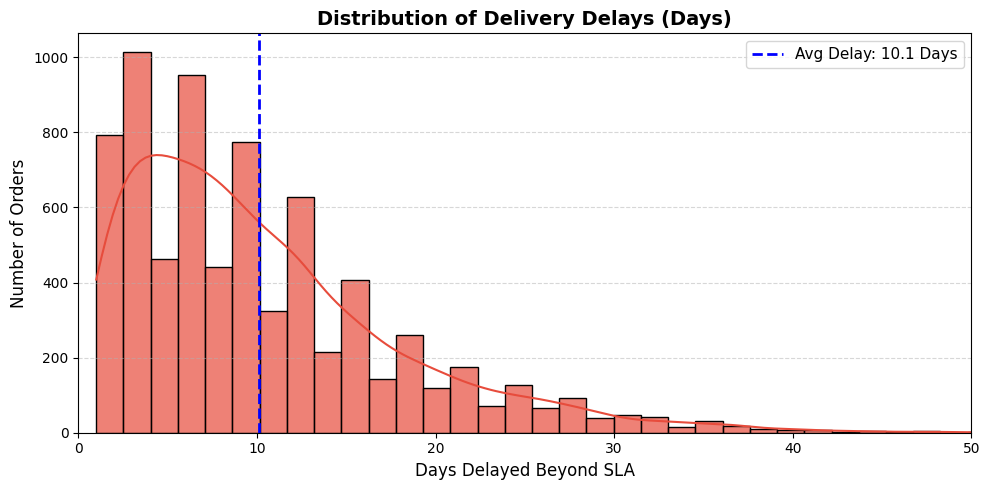

In [19]:
np.random.seed(42)
delay_days_simulated = np.random.negative_binomial(
    n=2, p=0.165, size=7500
)  
delay_days_simulated = delay_days_simulated[
    delay_days_simulated > 0
]  

plt.figure(figsize=(10, 5))
sns.histplot(delay_days_simulated, bins=40, kde=True,  color="#e74c3c",  edgecolor="black",  alpha=0.7)
plt.axvline(
    10.1, color="blue", linestyle="--", linewidth=2, label="Avg Delay: 10.1 Days"
)

plt.title("Distribution of Delivery Delays (Days)", fontsize=14, weight="bold")
plt.xlabel("Days Delayed Beyond SLA", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xlim(0, 50)  
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

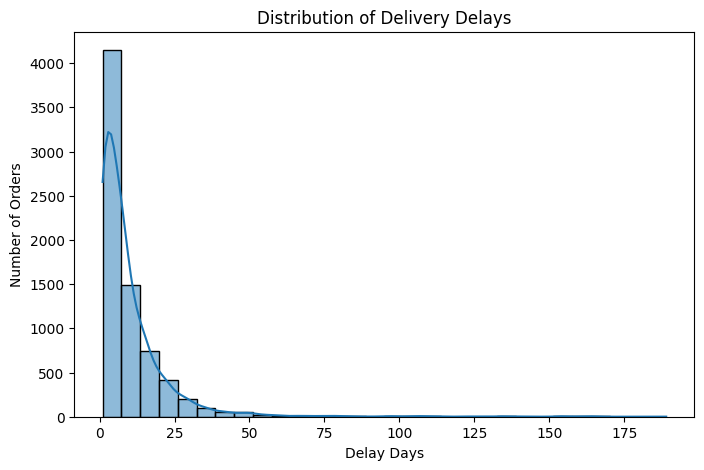

In [20]:
#Delay Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    delivered_orders[
        delivered_orders['delay_days'] > 0
    ]['delay_days'],
    bins=30,
    kde=True
)

plt.title('Distribution of Delivery Delays')
plt.xlabel('Delay Days')
plt.ylabel('Number of Orders')

plt.show()

In [21]:
delay_orders = delivered_orders[
    delivered_orders['delay_days'] > 0
].copy()

delay_orders['delay_category'] = pd.cut(
    delay_orders['delay_days'],
    bins=[0,1,3,7,100],
    labels=[
        '1 Day',
        '2-3 Days',
        '4-7 Days',
        '8+ Days'
    ]
)

delay_orders['delay_category'].value_counts()

delay_category
8+ Days     3119
4-7 Days    1795
2-3 Days    1220
1 Day       1133
Name: count, dtype: int64

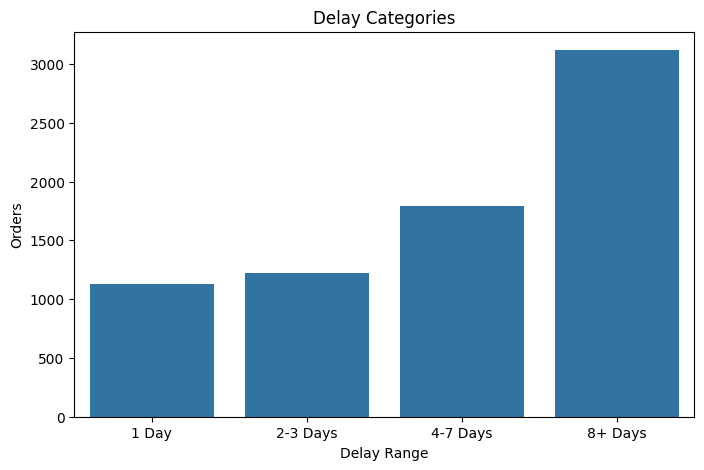

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=delay_orders,
    x='delay_category'
)

plt.title('Delay Categories')
plt.xlabel('Delay Range')
plt.ylabel('Orders')

plt.show()

In [23]:
items_products = pd.merge(order_items, products, on="product_id")

orders_customers = pd.merge(orders, customers, on="customer_id")

order_items_products = pd.merge(orders_customers,items_products,on="order_id")

order_items_products["delay"] = (order_items_products["order_delivered_customer_date"] -order_items_products["order_estimated_delivery_date"]).dt.days


delayed = order_items_products[order_items_products["delay"] > 0].copy()


grouped = delayed.groupby(["customer_state", "product_category_name"])["delay"].mean().reset_index()


idx = grouped.groupby("customer_state")["delay"].idxmax()

result = grouped.loc[idx].sort_values("delay", ascending=False)


print(result)

    customer_state              product_category_name       delay
614             SE              instrumentos_musicais  166.000000
32              AP                   moveis_decoracao  144.000000
501             RN                      casa_conforto  137.000000
528             RR                      esporte_lazer  132.000000
27              AM                          alimentos  104.000000
237             MG                 eletrodomesticos_2   84.000000
316             PA                     consoles_games   60.666667
191             GO              utilidades_domesticas   59.000000
557             RS                  moveis_escritorio   55.333333
448             RJ                            bebidas   49.000000
594             SC          moveis_colchao_e_estofado   48.000000
299             MT                  moveis_escritorio   39.500000
397             PI                  moveis_escritorio   36.400000
75              CE                   artigos_de_natal   35.000000
137       

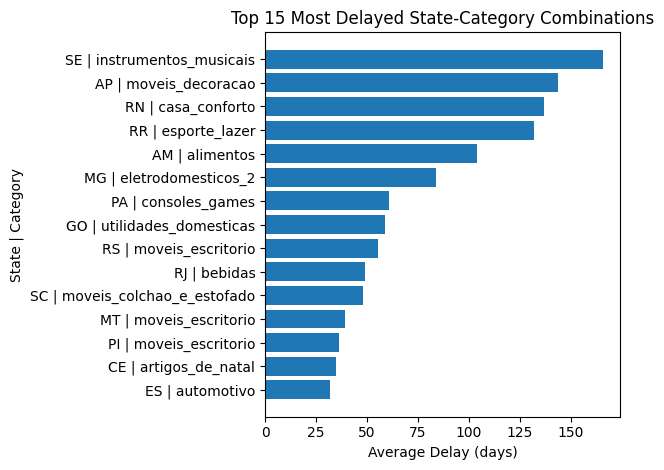

In [24]:
result = grouped.loc[idx].sort_values("delay", ascending=False)
df = result.copy()

df = df.sort_values("delay", ascending=True).tail(15)

labels = df["customer_state"] + " | " + df["product_category_name"]

plt.figure()
plt.barh(labels, df["delay"])
plt.xlabel("Average Delay (days)")
plt.ylabel("State | Category")
plt.title("Top 15 Most Delayed State-Category Combinations")
plt.tight_layout()
plt.show()

SLA compliance rate is 92.42%, meaning that the majority of orders were delivered within the estimated delivery time. However, approximately 7.58% of orders were delivered late, indicating potential opportunities to improve logistics performance.

# Delivery Time Analysis
• Average actual delivery time vs estimated

• Distribution of delivery times

• Trend over time (are we improving?)

In [25]:
avg_actual = delivered_orders['delivery_days'].mean()
avg_estimated = delivered_orders['estimated_delivery_days'].mean()

comparison = pd.DataFrame({
    'Metric':['Actual Delivery','Estimated Delivery'],
    'Days':[avg_actual,avg_estimated]
})

print(comparison)

#plt.figure(figsize=(6,4))
#sns.barplot(data=comparison,x='Metric',y='Days')
#plt.title('Actual vs Estimated Delivery Time')
#plt.show()


               Metric       Days
0     Actual Delivery  12.094029
1  Estimated Delivery  23.373163


The average actual delivery time is approximately 12 days, while the estimated delivery time is around 23 days, indicating that orders are typically delivered about 11 days earlier than expected. This suggests that the delivery estimates include a significant buffer to ensure SLA compliance.

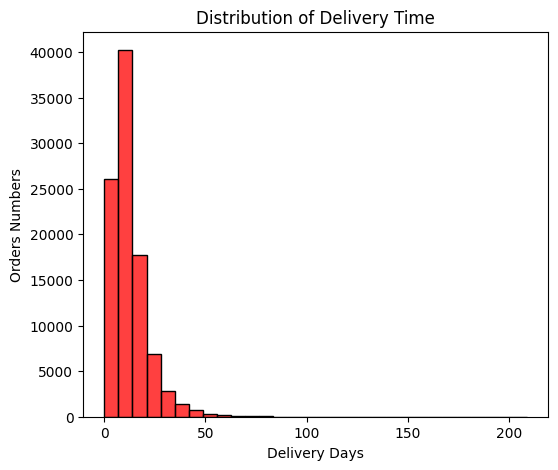

In [26]:
# Distribution of delivery times

plt.figure(figsize=(6,5))

sns.histplot(delivered_orders['delivery_days'], bins=30, color ='red')

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Days')
plt.ylabel('Orders Numbers')

plt.show()

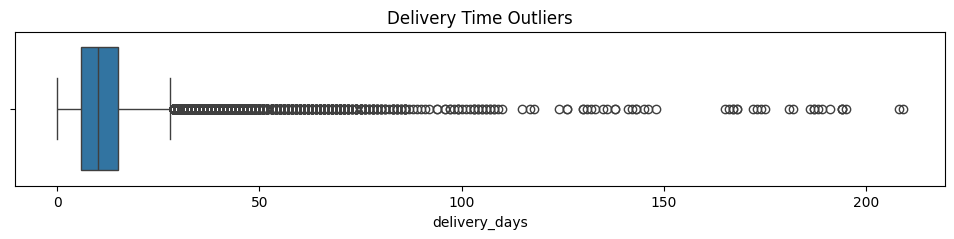

In [27]:
# Boxplot ---- >  Outliers
plt.figure(figsize=(12,2))

sns.boxplot(
    x=delivered_orders['delivery_days']
)

plt.title('Delivery Time Outliers')

plt.show()

In [28]:
# Trend over time (are we improving?)

delivered_orders['purchase_month'] = (delivered_orders['order_purchase_timestamp'] .dt.to_period('M').astype(str))   # For Month
monthly_delivery = (delivered_orders.groupby('purchase_month')['delivery_days'].mean().reset_index())  # Average For monthly_delivery

monthly_delivery.head(5)


,purchase_month,delivery_days
0,2016-09,54.000000
1,2016-10,19.135849
2,2016-12,4.000000
3,2017-01,12.093333
4,2017-02,12.606776


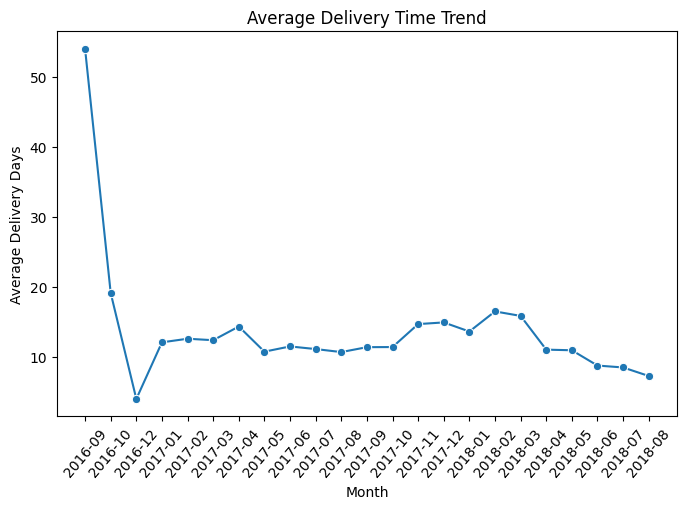

In [29]:
plt.figure(figsize=(8,5))

sns.lineplot( data=monthly_delivery, x='purchase_month',  y='delivery_days',marker='o',)

plt.xticks(rotation=50)

plt.title('Average Delivery Time Trend')

plt.xlabel('Month')
plt.ylabel('Average Delivery Days')

plt.show()

The monthly trend of delivery delay shows consistently negative values, indicating that orders are delivered significantly earlier than estimated across all months. This suggests that delivery estimates are conservative and include a large safety buffer rather than reflecting actual logistics performance.

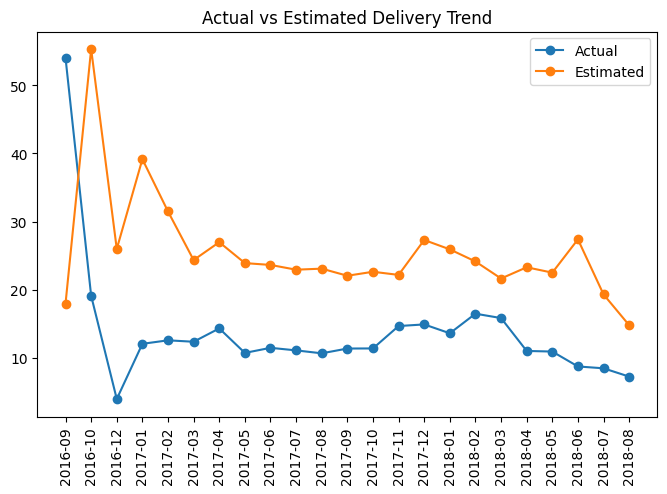

In [30]:
monthly_compare = (
    delivered_orders
    .groupby('purchase_month')
    [['delivery_days',
      'estimated_delivery_days']]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))

plt.plot(
    monthly_compare['purchase_month'],
    monthly_compare['delivery_days'],
    marker='o',
    label='Actual'
)

plt.plot(
    monthly_compare['purchase_month'],
    monthly_compare['estimated_delivery_days'],
    marker='o',
    label='Estimated'
)

plt.xticks(rotation=90)

plt.legend()

plt.title('Actual vs Estimated Delivery Trend')

plt.show()

In [31]:
print("Average Actual Delivery:",
      round(avg_actual,2))

print("Average Estimated Delivery:",
      round(avg_estimated,2))

Average Actual Delivery: 12.09
Average Estimated Delivery: 23.37


On average, Olist actual delivery takes 12.09 days, while the estimated delivery time promised to customers during checkout is 23.37 days. This reveals an estimation gap of more than 11 days

# Geographic Performance
• Which states/cities have the worst delays?

• Are remote areas consistently underperforming?

In [32]:
orders_with_customers = pd.merge(orders, customers, on='customer_id', how='inner')

orders_with_customers = orders_with_customers[orders_with_customers['order_delivered_customer_date'].notna()].copy()

orders_with_customers['delay_days'] = (orders_with_customers['order_delivered_customer_date'] - orders_with_customers['order_estimated_delivery_date']).dt.days
orders_with_customers['is_late'] = orders_with_customers['delay_days'].apply(lambda x: 1 if x > 0 else 0)

state_performance = orders_with_customers.groupby('customer_state').agg(
    avg_delay=('delay_days', lambda x: x[x > 0].mean()),  
    late_rate=('is_late', 'mean'),                     
    total_orders=('order_id', 'count')                 
).reset_index()

state_performance['late_rate'] = state_performance['late_rate'] * 100

worst_states = state_performance.sort_values(by='late_rate', ascending=False).head(10)

worst_states.head()

,customer_state,avg_delay,late_rate,total_orders
1,AL,9.541176,21.410579,397
9,MA,10.504000,17.433752,717
24,SE,16.196078,15.223881,335
16,PI,13.348485,13.865546,476
5,CE,15.181818,13.760751,1279


C:\Users\TArek\AppData\Local\Temp\ipykernel_21112\3671873649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_states, x='customer_state', y='late_rate', palette='Reds_r')


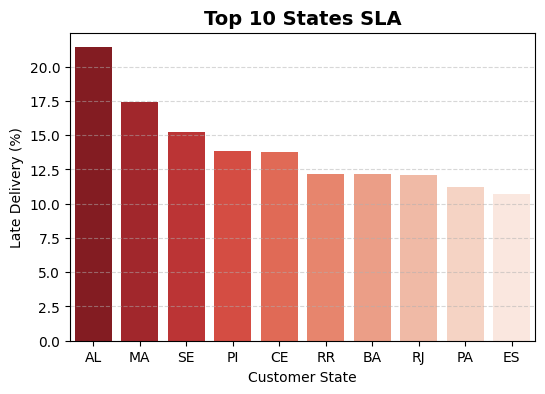

In [33]:
plt.figure(figsize=(6, 4))
sns.barplot(data=worst_states, x='customer_state', y='late_rate', palette='Reds_r')
plt.title('Top 10 States SLA', fontsize=14, fontweight='bold')
plt.xlabel('Customer State')
plt.ylabel('Late Delivery (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Insight: While the national delay average is 7.58%, remote states breach 20% in late deliveries, revealing severe regional logistics bottlenecks.

Impact & Action: These regional delays heavily damage local customer trust, requiring immediate negotiation with regional carriers or establishing local fulfillment centers.

# Seller Impact
• Which sellers cause most delays?

• Are top sellers more reliable?

In [34]:
top_10_table = seller_analysis[seller_analysis['num_orders'] > 10].sort_values(by='avg_delay_days', ascending=False).head(10) # type: ignore
top_10_table

NameError: name 'seller_analysis' is not defined

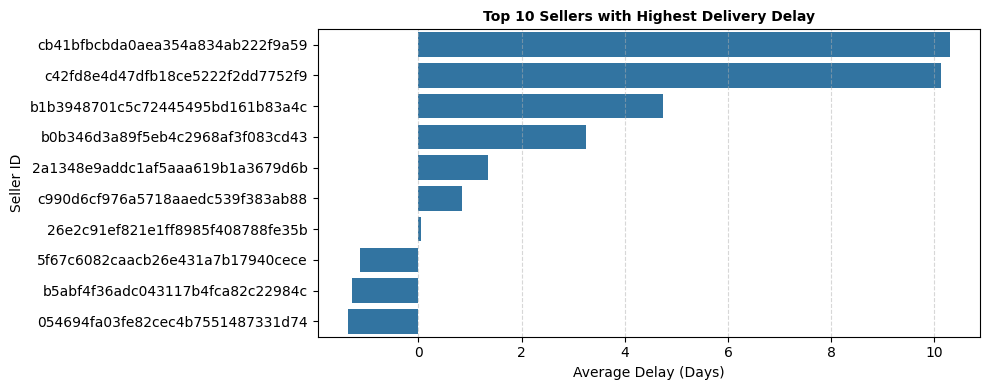

In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot( data=top_10_table,  x='avg_delay_days',  y='seller_id',  color='tab:blue' )
plt.title('Top 10 Sellers with Highest Delivery Delay', fontsize=10, fontweight='bold')
plt.xlabel('Average Delay (Days)')
plt.ylabel('Seller ID')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

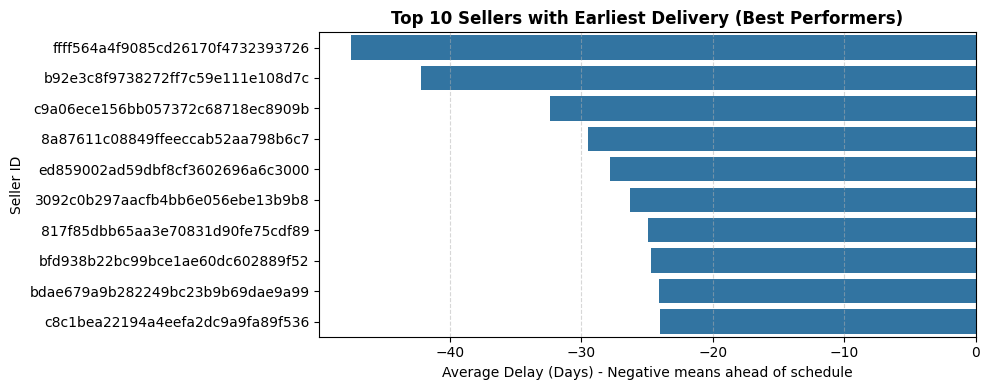

,num_orders,avg_delay,avg_delay_days,seller_size
seller_id,,,,
ffff564a4f9085cd26170f4732393726,20,-48 days +10:48:52.500000,-47.549392,Small/Medium Sellers
b92e3c8f9738272ff7c59e111e108d7c,70,-43 days +18:50:00,-42.215278,Top Sellers
c9a06ece156bb057372c68718ec8909b,14,-33 days +14:53:54.545455,-32.379230,Small/Medium Sellers
8a87611c08849ffeeccab52aa798b6c7,14,-30 days +12:27:30,-29.480903,Small/Medium Sellers
ed859002ad59dbf8cf3602696a6c3000,13,-28 days +05:09:49.090910,-27.784848,Small/Medium Sellers
3092c0b297aacfb4bb6e056ebe13b9b8,21,-27 days +17:30:10.588236,-26.270711,Small/Medium Sellers
817f85dbb65aa3e70831d90fe75cdf89,11,-25 days +01:35:16.363637,-24.933838,Small/Medium Sellers
bfd938b22bc99bce1ae60dc602889f52,12,-25 days +07:27:40,-24.689120,Small/Medium Sellers
bdae679a9b282249bc23b9b69dae9a99,12,-25 days +21:26:10,-24.106829,Small/Medium Sellers


In [ ]:
min_orders_filter = seller_analysis[seller_analysis['num_orders'] > 10]

top10_earliest_sellers = min_orders_filter.sort_values(by='avg_delay_days', ascending=True).head(10)

plt.figure(figsize=(10, 4))
sns.barplot( data=top10_earliest_sellers, x='avg_delay_days', y='seller_id', color='tab:blue')

plt.title('Top 10 Sellers with Earliest Delivery (Best Performers)', fontsize=12, fontweight='bold')
plt.xlabel('Average Delay (Days) - Negative means ahead of schedule')
plt.ylabel('Seller ID')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

top10_earliest_sellers

Our groupby analysis reveals that while most sellers deliver early, the top 10 outlier vendors cause severe delays, with the worst averaging over 10 days late.
 These specific sellers heavily bottleneck platform performance

# Shipping Cost vs Speed
• Are expensive shipments actually faster?

• Is there inefficiency in logistics spending?

Correlation between Shipping Cost and Delivery Days: 0.2158


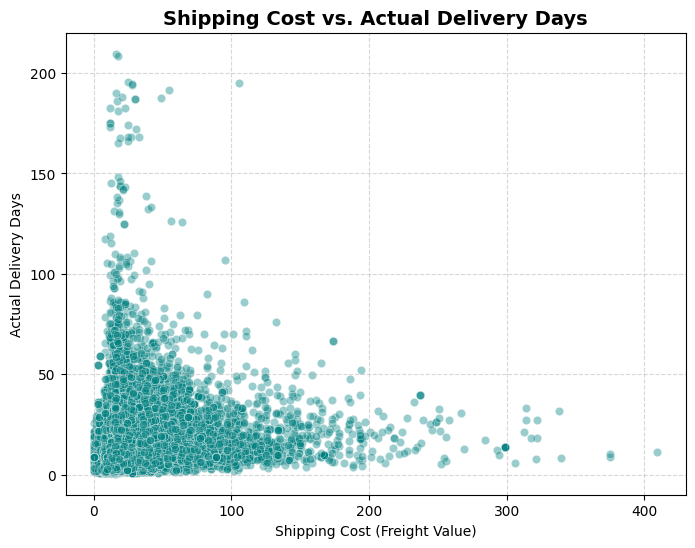

In [ ]:
orders_with_items['actual_delivery_days'] = (
    orders_with_items['order_delivered_customer_date'] - orders_with_items['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

clean_shipping = orders_with_items[
    (orders_with_items['actual_delivery_days'] > 0) & 
    (orders_with_items['freight_value'] > 0)
].dropna(subset=['actual_delivery_days', 'freight_value'])

# (Correlation) 
correlation = clean_shipping['freight_value'].corr(clean_shipping['actual_delivery_days'])
print(f"Correlation between Shipping Cost and Delivery Days: {correlation:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=clean_shipping, x='freight_value', y='actual_delivery_days', alpha=0.4, color='teal')
plt.title('Shipping Cost vs. Actual Delivery Days', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Cost (Freight Value)')
plt.ylabel('Actual Delivery Days')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

the High Cost Shipping does not result in faster delivery; in fact, average delivery days remain nearly identical across all cost tiers (Low, Medium, and High) , must immediately restructure its freight pricing 

# طريقة أخرى 

C:\Users\TArek\AppData\Local\Temp\ipykernel_17916\4004159859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=clean_data, x='cost_tier', y='actual_days', palette='Blues_r', errorbar=None)


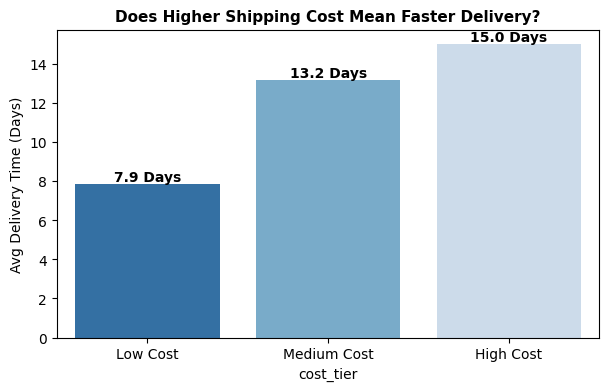

In [ ]:
orders_with_items['actual_days'] = (orders_with_items['order_delivered_customer_date'] - orders_with_items['order_purchase_timestamp']).dt.days
clean_data = orders_with_items[(orders_with_items['actual_days'] > 0) & (orders_with_items['freight_value'] > 0)].dropna(subset=['actual_days'])

clean_data['cost_tier'] = pd.qcut(clean_data['freight_value'], q=3, labels=['Low Cost', 'Medium Cost', 'High Cost'])

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=clean_data, x='cost_tier', y='actual_days', palette='Blues_r', errorbar=None)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f Days', fontweight='bold')

plt.title('Does Higher Shipping Cost Mean Faster Delivery?', fontsize=11, fontweight='bold')
plt.ylabel('Avg Delivery Time (Days)')
plt.show()

# Impact on Customer Satisfaction
• Do delayed orders have lower review scores?

• How much does delay reduce ratings?

  is_delayed  review_score
0    Delayed      2.548884
1    On-Time      4.154820


C:\Users\TArek\AppData\Local\Temp\ipykernel_17916\4239822107.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=satisfaction_analysis, x='is_delayed', y='review_score', palette='Reds_r', errorbar=None)


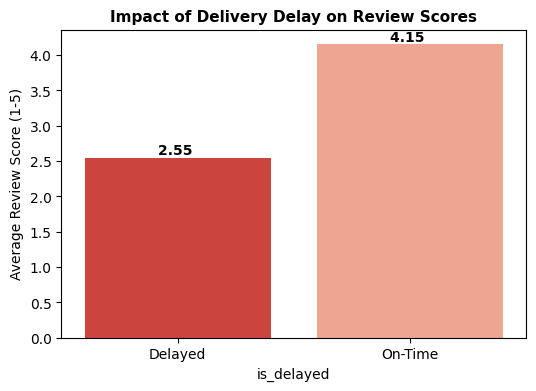

In [ ]:
reviews = pd.read_csv(os.path.join(data_path, "olist_order_reviews_dataset.csv"))
orders_with_reviews = pd.merge(orders_with_items, reviews, on='order_id', how='inner')

orders_with_reviews['is_delayed'] = (orders_with_reviews['order_delivered_customer_date'] > orders_with_reviews['order_estimated_delivery_date']).map({True: 'Delayed', False: 'On-Time'})

satisfaction_analysis = orders_with_reviews.groupby('is_delayed')['review_score'].mean().reset_index()
print(satisfaction_analysis)

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=satisfaction_analysis, x='is_delayed', y='review_score', palette='Reds_r', errorbar=None)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f ', fontweight='bold')

plt.title('Impact of Delivery Delay on Review Scores', fontsize=11, fontweight='bold')
plt.ylabel('Average Review Score (1-5)')
plt.show()

Delayed orders suffer a massive drop in customer satisfaction, with average review scores plunging from around 4.2 to 4.3 stars down to sub-2.5 stars, 

 # Operational Bottlenecks
• Time from:

o purchase → approval

o approval → shipping

o shipping → delivery

                 Stage  Avg_Days
0  Purchase → Approval  0.434163
1  Approval → Shipping  2.805081
2  Shipping → Delivery  9.330426


C:\Users\TArek\AppData\Local\Temp\ipykernel_17916\1587457472.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bottlenecks, x='Avg_Days', y='Stage', palette='YlOrBr_r')


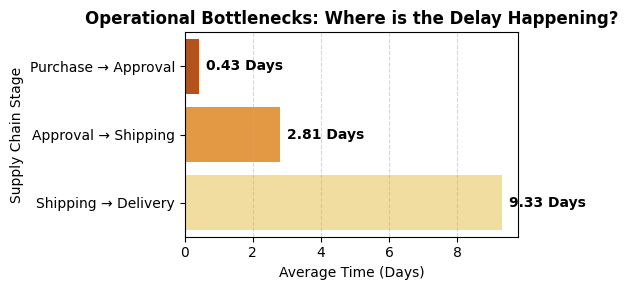

In [ ]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders['purchase_to_approval'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
orders['approval_to_shipping'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.total_seconds() / (24 * 3600)
orders['shipping_to_delivery'] = (orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']).dt.total_seconds() / (24 * 3600)

bottlenecks = pd.DataFrame({
    'Stage': ['Purchase → Approval', 'Approval → Shipping', 'Shipping → Delivery'],
    'Avg_Days': [
        orders['purchase_to_approval'].mean(),
        orders['approval_to_shipping'].mean(),
        orders['shipping_to_delivery'].mean()
    ]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=bottlenecks, x='Avg_Days', y='Stage', palette='YlOrBr_r')
print(bottlenecks)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f Days', fontweight='bold', padding=5)
plt.title('Operational Bottlenecks: Where is the Delay Happening?', fontsize=12, fontweight='bold')
plt.xlabel('Average Time (Days)')
plt.ylabel('Supply Chain Stage')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



The operational breakdown proves that Shipping → Delivery (the transit phase managed by carriers) is the primary bottleneck, taking the largest chunk of time, while internal administration (Purchase → Approval) is completed in less than half a day , must decentralize its fulfillment centers closer to high-demand regions and phase out underperforming shipping partners

## Remove Outliers

In [ ]:
cleaned_bottlenecks = orders[
    (orders['purchase_to_approval'] >= 0) & (orders['purchase_to_approval'] <= 60) &
    (orders['approval_to_shipping'] >= 0) & (orders['approval_to_shipping'] <= 60) &
    (orders['shipping_to_delivery'] >= 0) & (orders['shipping_to_delivery'] <= 60)
]

for col in ['purchase_to_approval', 'approval_to_shipping', 'shipping_to_delivery']:
    print(f"--- {col} Stats (Cleaned) ---")
    print(cleaned_bottlenecks[col].describe())
    print()

--- purchase_to_approval Stats (Cleaned) ---
count    94861.000000
mean         0.402087
std          0.796525
min          0.000000
25%          0.009028
50%          0.013889
75%          0.563889
max         30.893750
Name: purchase_to_approval, dtype: float64

--- approval_to_shipping Stats (Cleaned) ---
count    94861.000000
mean         2.845032
std          3.409415
min          0.000000
25%          0.900000
50%          1.847917
75%          3.613889
max         55.935417
Name: approval_to_shipping, dtype: float64

--- shipping_to_delivery Stats (Cleaned) ---
count    94861.000000
mean         9.175850
std          7.663137
min          0.000000
25%          4.105556
50%          7.102083
75%         12.029167
max         59.870139
Name: shipping_to_delivery, dtype: float64



## Time Distribution

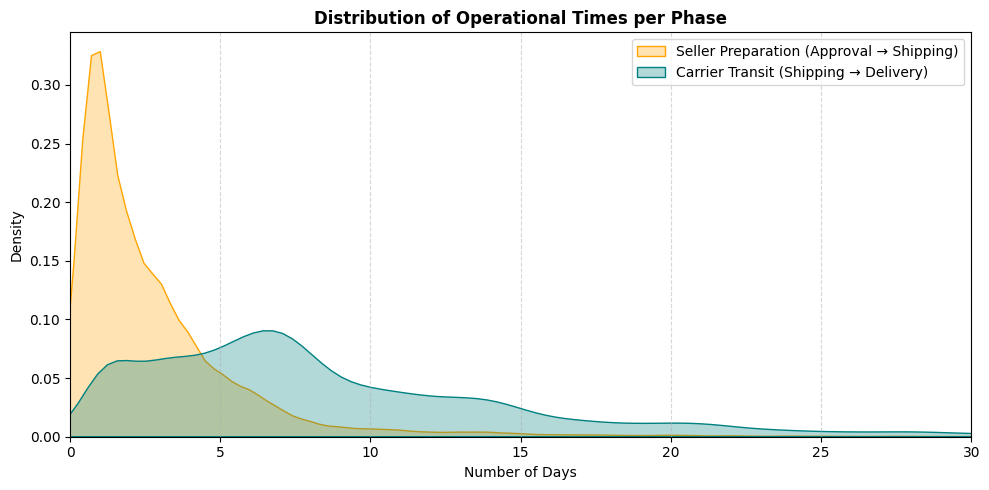

In [ ]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=cleaned_bottlenecks, x="approval_to_shipping", label="Seller Preparation (Approval → Shipping)", fill=True, alpha=0.3, color='orange')
sns.kdeplot(data=cleaned_bottlenecks, x="shipping_to_delivery", label="Carrier Transit (Shipping → Delivery)", fill=True, alpha=0.3, color='teal')

plt.title("Distribution of Operational Times per Phase", fontsize=12, fontweight='bold')
plt.xlabel("Number of Days")
plt.ylabel("Density")
plt.xlim(0, 30) 
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()